# Amazon Product Recommendation System

Amazon Product Content-Based Recommendation System

In [0]:
# Read CSV file from Volumes
df = spark.read.csv(
    "/Volumes/workspace/default/analysis/7817_1.csv",
    header=True,
    inferSchema=True
)

# Convert to pandas for easier manipulation
import pandas as pd
from pyspark.sql import functions as F

# Display basic info
print(f"Total rows: {df.count()}")
print(f"Total columns: {len(df.columns)}")
print("\nSchema:")
df.printSchema()

# Show sample data
display(df.limit(5))

Total rows: 1597
Total columns: 27

Schema:
root
 |-- id: string (nullable = true)
 |-- asins: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- colors: string (nullable = true)
 |-- dateAdded: timestamp (nullable = true)
 |-- dateUpdated: timestamp (nullable = true)
 |-- dimension: string (nullable = true)
 |-- ean: double (nullable = true)
 |-- keys: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- manufacturerNumber: string (nullable = true)
 |-- name: string (nullable = true)
 |-- prices: string (nullable = true)
 |-- reviews.date: string (nullable = true)
 |-- reviews.doRecommend: string (nullable = true)
 |-- reviews.numHelpful: string (nullable = true)
 |-- reviews.rating: string (nullable = true)
 |-- reviews.sourceURLs: string (nullable = true)
 |-- reviews.text: string (nullable = true)
 |-- reviews.title: string (nullable = true)
 |-- reviews.userCity: string (nullable = true)
 |-- reviews.us

id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,manufacturerNumber,name,prices,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",null,2016-03-08T20:21:53.000Z,2017-07-18T23:52:58.000Z,169 mm x 117 mm x 9.1 mm,null,kindlepaperwhite/b00qjdu3ky,Amazon,null,Kindle Paperwhite,"""[{""""amountMax"""":139.99","""""amountMin"""":139.99","""""currency"""":""""USD""""","""""dateAdded"""":""""2017-07-18T23:52:58Z""""","""""dateSeen"""":[""""2017-07-15T18:10:23.807Z""""","""""2016-03-16T00:00:00Z""""]","""""isSale"""":""""false""""","""""merchant"""":""""Amazon.com""""","""""shipping"""":""""FREE Shipping.""""","""""sourceURLs"""":[""""https://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built/dp/B00QJDU3KY/ref=lp_6669702011_1_7/132-1677641-8459202?s=amazon-devices&ie=UTF8&qid=1498832761&sr=1-7""""","""""http://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built-/dp/B00QJDU3KY""""]}","{""""amountMax"""":119.99","""""amountMin"""":119.99","""""condition"""":""""new"""""
AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",null,2016-03-08T20:21:53.000Z,2017-07-18T23:52:58.000Z,169 mm x 117 mm x 9.1 mm,null,kindlepaperwhite/b00qjdu3ky,Amazon,null,Kindle Paperwhite,"""[{""""amountMax"""":139.99","""""amountMin"""":139.99","""""currency"""":""""USD""""","""""dateAdded"""":""""2017-07-18T23:52:58Z""""","""""dateSeen"""":[""""2017-07-15T18:10:23.807Z""""","""""2016-03-16T00:00:00Z""""]","""""isSale"""":""""false""""","""""merchant"""":""""Amazon.com""""","""""shipping"""":""""FREE Shipping.""""","""""sourceURLs"""":[""""https://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built/dp/B00QJDU3KY/ref=lp_6669702011_1_7/132-1677641-8459202?s=amazon-devices&ie=UTF8&qid=1498832761&sr=1-7""""","""""http://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built-/dp/B00QJDU3KY""""]}","{""""amountMax"""":119.99","""""amountMin"""":119.99","""""condition"""":""""new"""""
AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",null,2016-03-08T20:21:53.000Z,2017-07-18T23:52:58.000Z,169 mm x 117 mm x 9.1 mm,null,kindlepaperwhite/b00qjdu3ky,Amazon,null,Kindle Paperwhite,"""[{""""amountMax"""":139.99","""""amountMin"""":139.99","""""currency"""":""""USD""""","""""dateAdded"""":""""2017-07-18T23:52:58Z""""","""""dateSeen"""":[""""2017-07-15T18:10:23.807Z""""","""""2016-03-16T00:00:00Z""""]","""""isSale"""":""""false""""","""""merchant"""":""""Amazon.com""""","""""shipping"""":""""FREE Shipping.""""","""""sourceURLs"""":[""""https://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built/dp/B00QJDU3KY/ref=lp_6669702011_1_7/132-1677641-8459202?s=amazon-devices&ie=UTF8&qid=1498832761&sr=1-7""""","""""http://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built-/dp/B00QJDU3KY""""]}","{""""amountMax"""":119.99","""""amountMin"""":119.99","""""condition"""":""""new"""""
AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",null,2016-03-08T20:21:53.000Z,2017-07-18T23:52:58.000Z,169 mm x 117 mm x 9.1 mm,null,kindlepaperwhite/b00qjdu3ky,Amazon,null,Kindle Paperwhite,"""[{""""amountMax"""":139.99","""""amountMin"""":139.99","""""currency"""":""""USD""""","""""dateAdded"""":""""2017-07-18T23:52:58Z""""","""""dateSeen"""":[""""2017-07-15T18:10:23.807Z""""","""""2016-03-16T00:00:00Z""""]","""""isSale"""":""""false""""","""""merchant"""":""""Amazon.com""""","""""shipping"""":""""FREE Shipping.""""","""""sourceURLs"""":[""""https://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built/dp/B00QJDU3KY/ref=lp_6669702011_1_7/132-1677641-8459202?s=amazon-devices&ie=UTF8&qid=1498832761&sr=1-7""""","""""http://www.amazon.com/Kindle-Paperwhite-High-Resolution-Display-Built-/dp/B00QJDU3KY""""]}","{""""amountMax"""":119.99","""""amountMin"""":119.9


DATA QUALITY ASSESSMENT

Note: The CSV file has malformed review data.
Review columns contain JSON fragments instead of actual reviews.
We'll build a CONTENT-BASED recommendation system using product attributes.

Missing values in product attribute columns:
  id: 0
  name: 0
  brand: 0
  categories: 0

Dataset statistics:
Total rows: 1597
Unique products (by id): 66
Unique products (by name): 62
Unique brands: 2


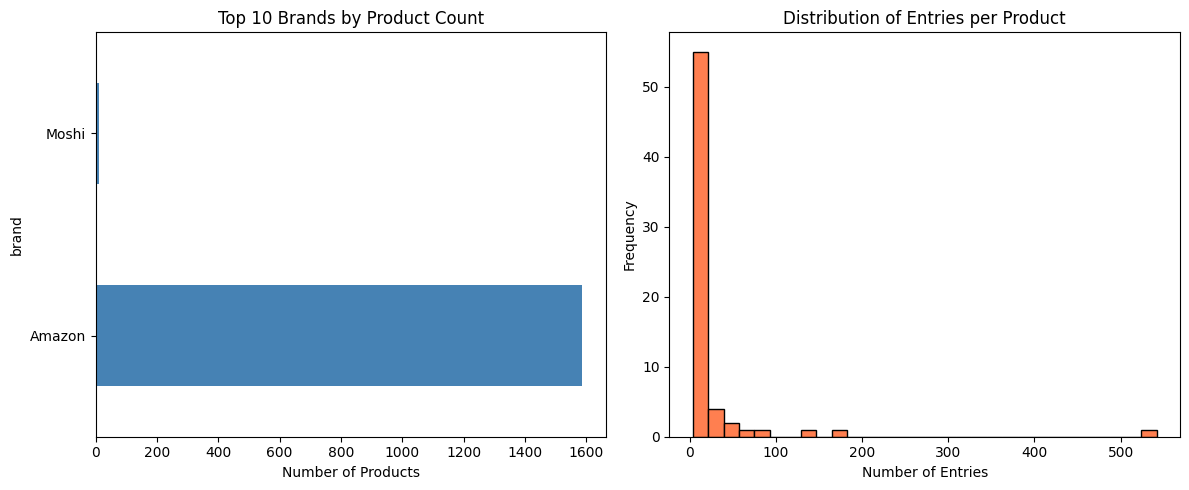


Top 5 products with most entries:
1. Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker   - 542 entries
2. Amazon Fire TV                                          - 166 entries
3. Amazon Premium Headphones                               - 133 entries
4. Fire HD 6 Tablet                                        - 87 entries
5. Kindle Fire HDX 7""                                     - 70 entries


In [0]:
# Exploratory Data Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to pandas for analysis
df_pd = df.toPandas()

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)
print(f"\nNote: The CSV file has malformed review data.")
print(f"Review columns contain JSON fragments instead of actual reviews.")
print(f"We'll build a CONTENT-BASED recommendation system using product attributes.")
print("="*60 + "\n")

# Check for missing values in key columns
print("Missing values in product attribute columns:")
key_cols = ['id', 'name', 'brand', 'categories']
for col in key_cols:
    print(f"  {col}: {df_pd[col].isnull().sum()}")

print(f"\nDataset statistics:")
print(f"Total rows: {len(df_pd)}")
print(f"Unique products (by id): {df_pd['id'].nunique()}")
print(f"Unique products (by name): {df_pd['name'].nunique()}")
print(f"Unique brands: {df_pd['brand'].nunique()}")

# Visualize brand and category distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
top_brands = df_pd['brand'].value_counts().head(10)
top_brands.plot(kind='barh', color='steelblue')
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Number of Products')

plt.subplot(1, 2, 2)
products_per_id = df_pd.groupby('id').size()
plt.hist(products_per_id, bins=30, edgecolor='black', color='coral')
plt.title('Distribution of Entries per Product')
plt.xlabel('Number of Entries')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nTop 5 products with most entries:")
top_products = df_pd.groupby(['id', 'name']).size().sort_values(ascending=False).head(5)
for idx, ((prod_id, prod_name), count) in enumerate(top_products.items(), 1):
    print(f"{idx}. {prod_name[:55]:55s} - {count} entries")

In [0]:
# Data Preprocessing for Content-Based Recommendations
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Prepare unique product catalog for content-based recommendations
df_products = df_pd[['id', 'name', 'brand', 'categories']].drop_duplicates(subset=['id']).copy()
df_products = df_products.fillna('')

print(f"Product catalog prepared:")
print(f"Total unique products: {len(df_products)}")
print(f"Products with brand info: {(df_products['brand'] != '').sum()}")
print(f"Products with category info: {(df_products['categories'] != '').sum()}")

# Combine features into a single text field for content matching
df_products['content'] = (
    df_products['name'] + ' ' + 
    df_products['brand'] + ' ' + 
    df_products['categories']
)

print(f"\nSample product content:")
for idx in range(min(3, len(df_products))):
    row = df_products.iloc[idx]
    print(f"\n{idx+1}. {row['name'][:60]}")
    print(f"   Brand: {row['brand']}")
    print(f"   Categories: {row['categories'][:70]}")

Product catalog prepared:
Total unique products: 66
Products with brand info: 66
Products with category info: 66

Sample product content:

1. Kindle Paperwhite
   Brand: Amazon
   Categories: Amazon Devices,mazon.co.uk

2. Kindle Keyboard
   Brand: Amazon
   Categories: Kindle Store,Amazon Devices,Electronics

3. Certified Refurbished Amazon Fire TV (Previous Generation - 
   Brand: Amazon
   Categories: Categories,Amazon Devices,Streaming Media Players


In [0]:
# Build Content-Based Recommendation Model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import mlflow
from datetime import datetime

print("Building Content-Based Recommendation Model...\n")

# Create TF-IDF matrix from product content
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = tfidf.fit_transform(df_products['content'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"(Products × Features)")

# Calculate cosine similarity between all products
print("\nCalculating product similarity matrix...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Similarity matrix shape: {cosine_sim.shape}")

# Log with MLflow
mlflow.set_experiment("/Users/shameemyusuf110@gmail.com/recommendation-system")

with mlflow.start_run(run_name=f"content_based_{datetime.now().strftime('%Y%m%d_%H%M%S')}"):
    mlflow.log_param("model_type", "content_based")
    mlflow.log_param("vectorizer", "TfidfVectorizer")
    mlflow.log_param("max_features", 500)
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("similarity_metric", "cosine")
    mlflow.log_param("n_products", len(df_products))
    
    # Log distribution of similarity scores
    avg_similarity = cosine_sim[np.triu_indices_from(cosine_sim, k=1)].mean()
    mlflow.log_metric("avg_similarity", avg_similarity)
    
print(f"\n✓ Model built successfully!")
print(f"Average product similarity: {avg_similarity:.4f}")

2026/09/12 07:45:06 INFO mlflow.tracking.fluent: Experiment with name '/Users/shameemyusuf110@gmail.com/recommendation-system' does not exist. Creating a new experiment.


Building Content-Based Recommendation Model...

TF-IDF matrix shape: (66, 414)
(Products × Features)

Calculating product similarity matrix...
Similarity matrix shape: (66, 66)


If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog



✓ Model built successfully!
Average product similarity: 0.1296


In [0]:
# Generate Content-Based Recommendations
import pandas as pd
import numpy as np

def get_similar_products(product_name, df=df_products, cosine_sim=cosine_sim, n=10):
    """
    Get similar products based on content features
    
    Args:
        product_name: Name (or partial name) of the product to find similar items for
        df: Products dataframe
        cosine_sim: Cosine similarity matrix
        n: Number of recommendations
    
    Returns:
        DataFrame with recommended products and similarity scores
    """
    # Find the index of the product (case-insensitive partial match)
    matches = df[df['name'].str.contains(product_name, case=False, na=False)]
    
    if len(matches) == 0:
        return None, "Product not found. Try a different name."
    
    idx = matches.index[0]
    product = df.iloc[idx]
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top N similar products (excluding itself)
    sim_scores = sim_scores[1:n+1]
    
    product_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]
    
    recommendations = df.iloc[product_indices][['id', 'name', 'brand', 'categories']].copy()
    recommendations['similarity_score'] = similarity_scores
    
    return product, recommendations

# Test recommendations with a sample product
sample_product = df_products['name'].iloc[0]
print(f"Finding products similar to: '{sample_product}'\n")
print("="*70)

original_product, recommendations = get_similar_products(sample_product, n=10)

if recommendations is not None:
    print(f"\nORIGINAL PRODUCT:")
    print(f"Name: {original_product['name']}")
    print(f"Brand: {original_product['brand']}")
    print(f"Categories: {original_product['categories'][:80]}")
    
    print(f"\n\nTOP 10 SIMILAR PRODUCTS:")
    print("="*70)
    display(recommendations[['name', 'brand', 'similarity_score']])
else:
    print(recommendations)

Finding products similar to: 'Kindle Paperwhite'


ORIGINAL PRODUCT:
Name: Kindle Paperwhite
Brand: Amazon
Categories: Amazon Devices,mazon.co.uk


TOP 10 SIMILAR PRODUCTS:


name,brand,similarity_score
Kindle Paperwhite,Amazon,0.4611306238251001
Kindle Paperwhite,Amazon,0.4076235605751506
Kindle Paperwhite E-reader - Black,Amazon,0.28872486789291013
Kindle Paperwhite E-reader - Black,Amazon,0.28872486789291013
Kindle Paperwhite 3G,Amazon,0.26600265261338196
Certified Refurbished Kindle Paperwhite E-reader - Black,Amazon,0.23123935278593608
Kindle,Amazon,0.1516542044141411
"Kindle Fire HD 7""""",Amazon,0.12352561639224735
Kindle E-reader - Black,Amazon,0.12191095804567437
Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,Amazon,0.11654410981392344
